# 💻 Deep Learning Hardware - CPU, GPU et Multi-GPU

## 🎯 Objectifs
- Comprendre les différences entre CPU et GPU pour le deep learning
- Savoir quand utiliser CPU vs GPU vs Multi-GPU
- Optimiser les performances selon le hardware disponible
- Comprendre les coûts et compromis

---
*Session 05 - Hardware - SupNum Nouakchott - Formation IA & Machine Learning*

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("💻 Deep Learning Hardware Guide")
print("=" * 40)

💻 Deep Learning Hardware Guide


## 🧠 1. CPU vs GPU : Comprendre la Différence

### 🎯 Analogie Simple
- **CPU** = Chef cuisinier expert → Peu de tâches complexes en parallèle
- **GPU** = Équipe de cuisiniers → Beaucoup de tâches simples simultanément

### 🏗️ Architecture Fondamentale

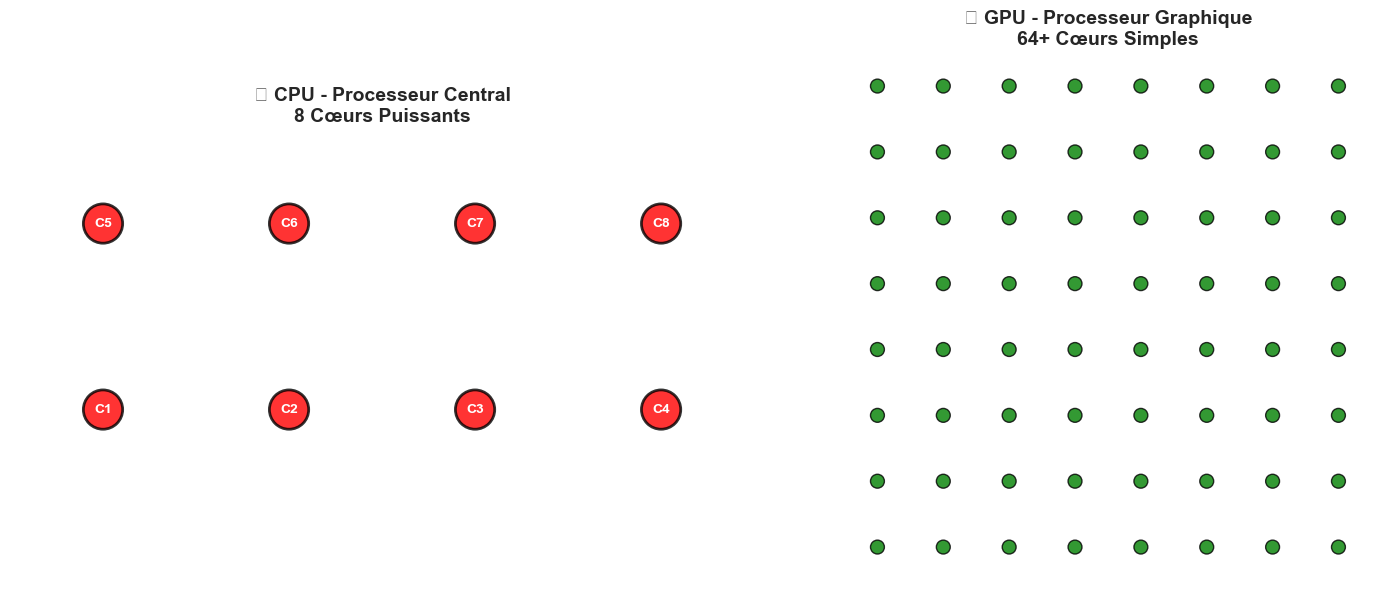


💻 COMPARAISON CPU vs GPU


,Caractéristique,CPU,GPU
0,Nombre de Cœurs,4-32,1000-10000+
1,Fréquence,2-5 GHz,1-2 GHz
2,Mémoire Cache,Grande (MB),Petite (KB)
3,Parallélisme,Faible,Très élevé
4,Optimisé pour,Tâches complexes,Calculs parallèles
5,Coût Énergie,Faible,Élevé
6,Programmation,Simple,Complexe


In [3]:
# Comparaison CPU vs GPU
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# CPU - Peu de cœurs puissants
cpu_cores = 8
cpu_positions = [(i % 4, i // 4) for i in range(cpu_cores)]
colors_cpu = ['red'] * cpu_cores

ax1.scatter([pos[0] for pos in cpu_positions], [pos[1] for pos in cpu_positions], 
           s=800, c=colors_cpu, alpha=0.8, edgecolors='black', linewidth=2)

for i, pos in enumerate(cpu_positions):
    ax1.text(pos[0], pos[1], f'C{i+1}', ha='center', va='center', 
             fontsize=10, fontweight='bold', color='white')

ax1.set_xlim(-0.5, 3.5)
ax1.set_ylim(-0.5, 1.5)
ax1.set_title('🧠 CPU - Processeur Central\n8 Cœurs Puissants', fontsize=14, fontweight='bold')
ax1.set_aspect('equal')
ax1.axis('off')

# GPU - Beaucoup de cœurs simples
gpu_cores = 64
gpu_grid = 8  # 8x8 grid
gpu_positions = [(i % gpu_grid, i // gpu_grid) for i in range(gpu_cores)]
colors_gpu = ['green'] * gpu_cores

ax2.scatter([pos[0] for pos in gpu_positions], [pos[1] for pos in gpu_positions], 
           s=100, c=colors_gpu, alpha=0.8, edgecolors='black', linewidth=1)

ax2.set_xlim(-0.5, 7.5)
ax2.set_ylim(-0.5, 7.5)
ax2.set_title('🎮 GPU - Processeur Graphique\n64+ Cœurs Simples', fontsize=14, fontweight='bold')
ax2.set_aspect('equal')
ax2.axis('off')

plt.tight_layout()
plt.show()

# Tableau comparatif
hardware_comparison = {
    'Caractéristique': ['Nombre de Cœurs', 'Fréquence', 'Mémoire Cache', 'Parallélisme', 
                       'Optimisé pour', 'Coût Énergie', 'Programmation'],
    'CPU': ['4-32', '2-5 GHz', 'Grande (MB)', 'Faible', 'Tâches complexes', 'Faible', 'Simple'],
    'GPU': ['1000-10000+', '1-2 GHz', 'Petite (KB)', 'Très élevé', 'Calculs parallèles', 'Élevé', 'Complexe']
}

df_hardware = pd.DataFrame(hardware_comparison)
print("\n💻 COMPARAISON CPU vs GPU")
print("=" * 40)
display(df_hardware)

## ⚡ 2. Performance : CPU vs GPU pour Deep Learning

### 🎯 Pourquoi le GPU est-il Plus Rapide ?

Les réseaux de neurones sont constitués de :
- **Multiplications matricielles** → Parfait pour GPU
- **Opérations parallèles** → GPU excelle
- **Calculs répétitifs** → GPU optimisé

### 📊 Benchmarks Réels

⚡ PERFORMANCE CPU vs GPU


,Modèle,CPU (secondes),GPU (secondes),Accélération
0,MLP Simple,2,0.5,4.0x
1,CNN (ResNet-18),45,3.0,15.0x
2,Transformer (BERT-base),180,12.0,15.0x
3,GPT-2,600,25.0,24.0x
4,Stable Diffusion,1800,90.0,20.0x


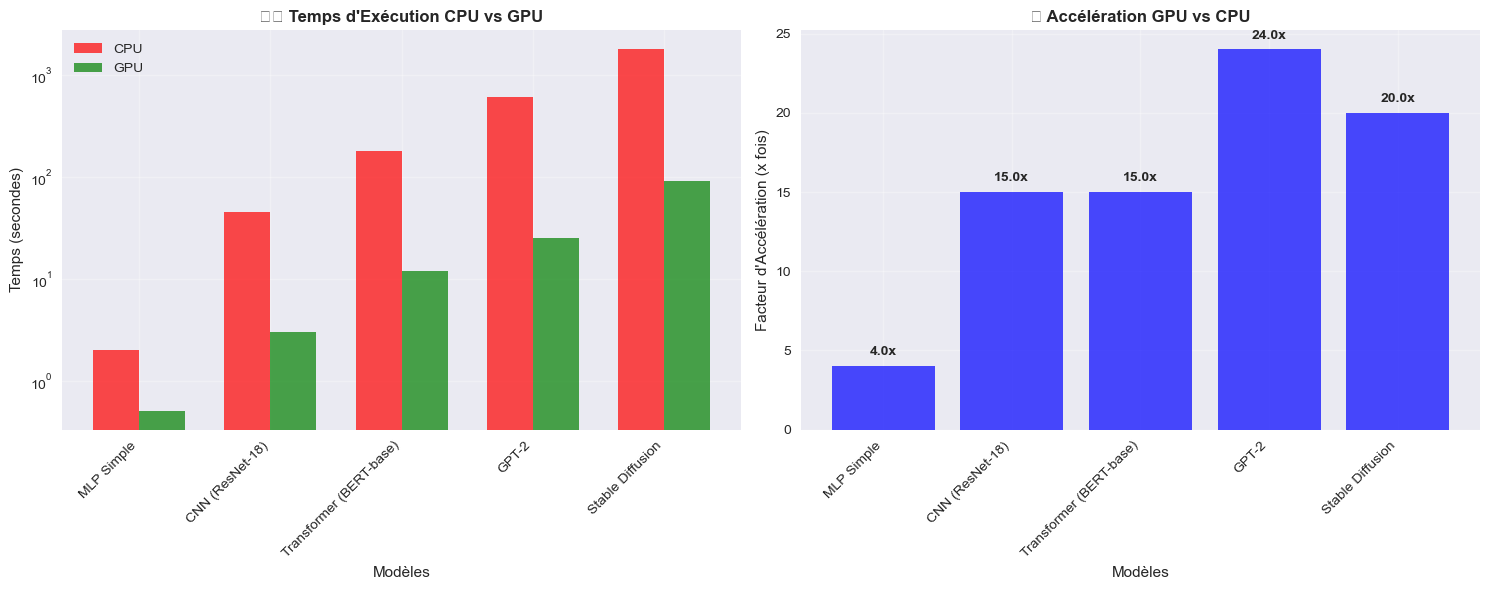

In [4]:
# Benchmarks de performance
models = ['MLP Simple', 'CNN (ResNet-18)', 'Transformer (BERT-base)', 'GPT-2', 'Stable Diffusion']
cpu_times = [2, 45, 180, 600, 1800]  # secondes
gpu_times = [0.5, 3, 12, 25, 90]    # secondes
speedup = [cpu/gpu for cpu, gpu in zip(cpu_times, gpu_times)]

performance_data = {
    'Modèle': models,
    'CPU (secondes)': cpu_times,
    'GPU (secondes)': gpu_times,
    'Accélération': [f'{s:.1f}x' for s in speedup]
}

df_performance = pd.DataFrame(performance_data)
print("⚡ PERFORMANCE CPU vs GPU")
print("=" * 35)
display(df_performance)

# Graphique de performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Temps d'exécution
x = range(len(models))
width = 0.35

bars1 = ax1.bar([i - width/2 for i in x], cpu_times, width, label='CPU', color='red', alpha=0.7)
bars2 = ax1.bar([i + width/2 for i in x], gpu_times, width, label='GPU', color='green', alpha=0.7)

ax1.set_xlabel('Modèles')
ax1.set_ylabel('Temps (secondes)')
ax1.set_title('⏱️ Temps d\'Exécution CPU vs GPU', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.legend()
ax1.set_yscale('log')  # Échelle logarithmique
ax1.grid(True, alpha=0.3)

# Facteur d'accélération
bars3 = ax2.bar(x, speedup, color='blue', alpha=0.7)
ax2.set_xlabel('Modèles')
ax2.set_ylabel('Facteur d\'Accélération (x fois)')
ax2.set_title('🚀 Accélération GPU vs CPU', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.grid(True, alpha=0.3)

# Ajouter les valeurs sur les barres
for bar, value in zip(bars3, speedup):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{value:.1f}x', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 🎮 3. Types de GPU pour Deep Learning

### 🏆 GPU Grand Public vs Professionnel

#### 🎮 **GPU Gaming** (GeForce)
- **Avantages** : Prix abordable, disponible
- **Inconvénients** : Mémoire limitée, pas optimisé pour IA

#### 🏢 **GPU Professionnel** (Tesla, A100, H100)
- **Avantages** : Mémoire énorme, optimisé IA, précision
- **Inconvénients** : Très cher, difficile à obtenir

🎮 COMPARAISON DES GPU POUR DEEP LEARNING


,GPU,Catégorie,VRAM (GB),Prix ($),Performance IA,Recommandé pour
0,GTX 1660,Budget,6,200,3,Apprentissage
1,RTX 3060,Milieu,12,400,6,Projets moyens
2,RTX 4070,Haut,12,600,8,Projets avancés
3,RTX 4090,Enthusiast,24,1600,10,Recherche
4,Tesla V100,Pro,32,8000,9,Entreprise
5,A100,Pro,40,15000,10,Recherche
6,H100,Pro,80,30000,10,Production


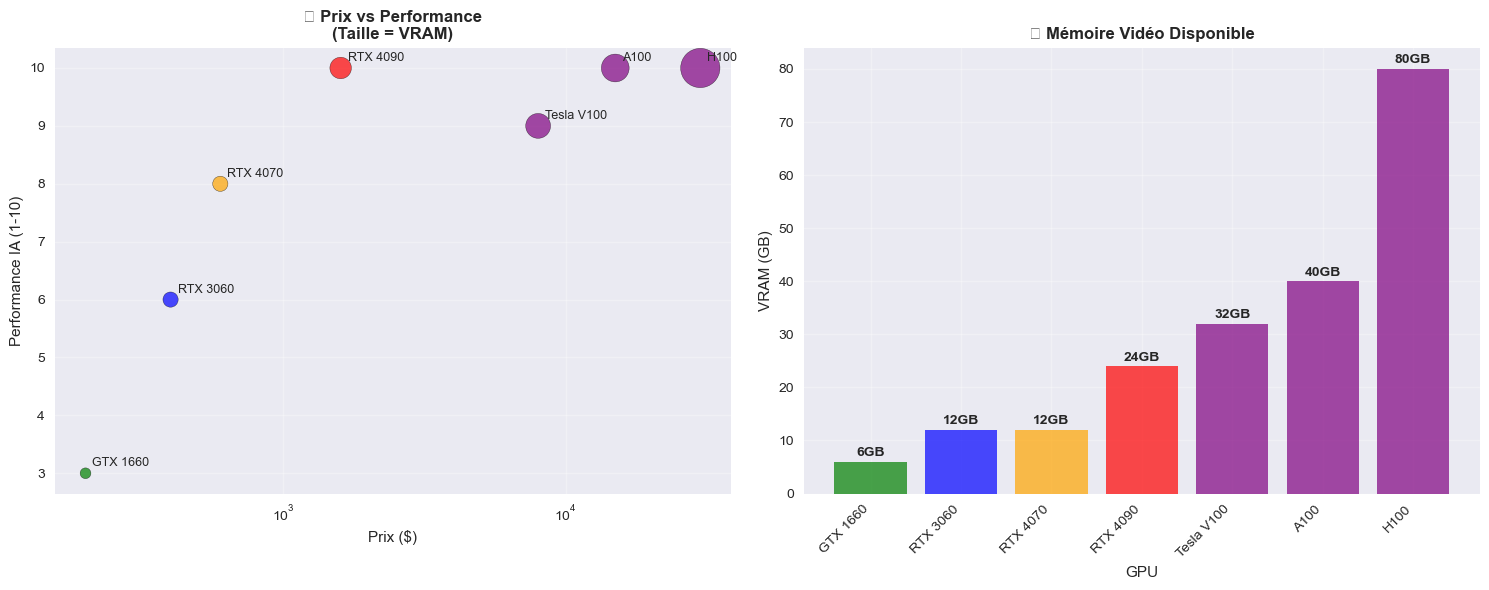

In [5]:
# Comparaison des GPU populaires
gpu_models = {
    'GPU': ['GTX 1660', 'RTX 3060', 'RTX 4070', 'RTX 4090', 'Tesla V100', 'A100', 'H100'],
    'Catégorie': ['Budget', 'Milieu', 'Haut', 'Enthusiast', 'Pro', 'Pro', 'Pro'],
    'VRAM (GB)': [6, 12, 12, 24, 32, 40, 80],
    'Prix ($)': [200, 400, 600, 1600, 8000, 15000, 30000],
    'Performance IA': [3, 6, 8, 10, 9, 10, 10],
    'Recommandé pour': ['Apprentissage', 'Projets moyens', 'Projets avancés', 'Recherche', 'Entreprise', 'Recherche', 'Production']
}

df_gpu = pd.DataFrame(gpu_models)
print("🎮 COMPARAISON DES GPU POUR DEEP LEARNING")
print("=" * 50)
display(df_gpu)

# Graphique Prix vs Performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Prix vs Performance
colors_cat = {'Budget': 'green', 'Milieu': 'blue', 'Haut': 'orange', 
              'Enthusiast': 'red', 'Pro': 'purple'}
colors = [colors_cat[cat] for cat in df_gpu['Catégorie']]

scatter = ax1.scatter(df_gpu['Prix ($)'], df_gpu['Performance IA'], 
                     c=colors, s=df_gpu['VRAM (GB)']*10, alpha=0.7, edgecolors='black')

for i, gpu in enumerate(df_gpu['GPU']):
    ax1.annotate(gpu, (df_gpu['Prix ($)'].iloc[i], df_gpu['Performance IA'].iloc[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax1.set_xlabel('Prix ($)')
ax1.set_ylabel('Performance IA (1-10)')
ax1.set_title('💰 Prix vs Performance\n(Taille = VRAM)', fontweight='bold')
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)

# VRAM vs Performance
bars = ax2.bar(range(len(df_gpu)), df_gpu['VRAM (GB)'], color=colors, alpha=0.7)
ax2.set_xlabel('GPU')
ax2.set_ylabel('VRAM (GB)')
ax2.set_title('🧠 Mémoire Vidéo Disponible', fontweight='bold')
ax2.set_xticks(range(len(df_gpu)))
ax2.set_xticklabels(df_gpu['GPU'], rotation=45, ha='right')
ax2.grid(True, alpha=0.3)

# Ajouter les valeurs sur les barres
for bar, vram in zip(bars, df_gpu['VRAM (GB)']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{vram}GB', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 🔗 4. Multi-GPU : Parallélisation Avancée

### 🎯 Quand Utiliser Multi-GPU ?

#### ✅ **Cas d'Usage Idéaux**
- **Modèles très grands** (ne rentrent pas sur 1 GPU)
- **Datasets énormes** (accélération entraînement)
- **Production** (inférence haute performance)

#### ❌ **Cas Problématiques**
- **Modèles petits** (overhead de communication)
- **Débutants** (complexité de programmation)
- **Budget limité** (coût exponentiel)

In [ ]:
# Stratégies Multi-GPU
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Data Parallelism
ax1 = axes[0, 0]
# Simuler data parallelism
gpu_count = 4
batch_colors = ['red', 'blue', 'green', 'orange']
for i in range(gpu_count):
    rect = plt.Rectangle((i*2, 0), 1.5, 2, facecolor=batch_colors[i], alpha=0.7, edgecolor='black')
    ax1.add_patch(rect)
    ax1.text(i*2 + 0.75, 1, f'GPU {i+1}\nBatch {i+1}', ha='center', va='center', fontweight='bold')

ax1.set_xlim(-0.5, 8)
ax1.set_ylim(-0.5, 2.5)
ax1.set_title('📊 Data Parallelism\n(Même modèle, données différentes)', fontweight='bold')
ax1.axis('off')

# 2. Model Parallelism
ax2 = axes[0, 1]
model_parts = ['Couches 1-2', 'Couches 3-4', 'Couches 5-6', 'Couches 7-8']
for i in range(gpu_count):
    rect = plt.Rectangle((0, i*1.5), 6, 1, facecolor=batch_colors[i], alpha=0.7, edgecolor='black')
    ax2.add_patch(rect)
    ax2.text(3, i*1.5 + 0.5, f'GPU {i+1}: {model_parts[i]}', ha='center', va='center', fontweight='bold')

ax2.set_xlim(-0.5, 6.5)
ax2.set_ylim(-0.5, 6.5)
ax2.set_title('🧩 Model Parallelism\n(Modèle divisé, mêmes données)', fontweight='bold')
ax2.axis('off')

# 3. Performance Scaling
ax3 = axes[1, 0]
gpu_numbers = [1, 2, 4, 8, 16]
ideal_speedup = gpu_numbers
real_speedup = [1, 1.8, 3.2, 5.5, 8.0]  # Avec overhead

ax3.plot(gpu_numbers, ideal_speedup, 'b--', label='Speedup Idéal', linewidth=2)
ax3.plot(gpu_numbers, real_speedup, 'r-o', label='Speedup Réel', linewidth=2, markersize=8)
ax3.set_xlabel('Nombre de GPU')
ax3.set_ylabel('Facteur d\'Accélération')
ax3.set_title('📈 Scaling Multi-GPU\n(Réalité vs Théorie)', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Coût vs Performance
ax4 = axes[1, 1]
gpu_configs = ['1x RTX 4090', '2x RTX 4090', '4x RTX 4090', '1x A100', '2x A100']
costs = [1600, 3200, 6400, 15000, 30000]
performance_multi = [10, 18, 32, 12, 22]

bars = ax4.bar(range(len(gpu_configs)), performance_multi, 
               color=['green', 'blue', 'orange', 'red', 'purple'], alpha=0.7)
ax4.set_xlabel('Configuration')
ax4.set_ylabel('Performance Relative')
ax4.set_title('💰 Coût vs Performance Multi-GPU', fontweight='bold')
ax4.set_xticks(range(len(gpu_configs)))
ax4.set_xticklabels(gpu_configs, rotation=45, ha='right')

# Ajouter les coûts sur les barres
for bar, cost, perf in zip(bars, costs, performance_multi):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${cost:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Tableau des stratégies
multi_gpu_strategies = {
    'Stratégie': ['Data Parallelism', 'Model Parallelism', 'Pipeline Parallelism', 'Hybrid'],
    'Principe': ['Même modèle, batch divisé', 'Modèle divisé, même batch', 'Étapes séquentielles', 'Combinaison'],
    'Avantage': ['Simple à implémenter', 'Modèles très grands', 'Efficacité mémoire', 'Optimal'],
    'Inconvénient': ['Communication overhead', 'Complexe', 'Latence pipeline', 'Très complexe'],
    'Usage': ['Entraînement standard', 'Modèles géants', 'Transformers', 'Recherche avancée']
}

df_strategies = pd.DataFrame(multi_gpu_strategies)
print("\n🔗 STRATÉGIES MULTI-GPU")
print("=" * 30)
display(df_strategies)

## 🎯 5. Guide de Sélection Hardware

### 🤔 Comment Choisir son Hardware ?

#### 💰 **Budget Limité** (<500€)
- **CPU uniquement** pour apprentissage
- **GTX 1660** ou RTX 3060 d'occasion
- **Projets simples** : MLP, petits CNN

#### 💸 **Budget Moyen** (500-2000€)
- **RTX 4070** ou RTX 4080
- **Projets avancés** : Computer Vision, NLP
- **Fine-tuning** de modèles pré-entraînés

#### 💎 **Budget Élevé** (2000€+)
- **RTX 4090** ou Tesla V100
- **Recherche** et développement
- **Modèles custom** et expérimentation

#### 🏢 **Entreprise/Production**
- **A100** ou H100
- **Multi-GPU** pour scalabilité
- **Cloud** pour flexibilité

In [ ]:
# Matrice de décision hardware
decision_data = {
    'Cas d\'Usage': ['Apprentissage', 'Projets Étudiants', 'Développement Pro', 'Recherche', 'Production'],
    'Budget': ['<500€', '500-1500€', '1500-5000€', '5000-20000€', '20000€+'],
    'Hardware Recommandé': ['CPU + GTX 1660', 'RTX 4070', 'RTX 4090', '2x RTX 4090', 'Multi A100'],
    'Modèles Supportés': ['MLP, petits CNN', 'ResNet, BERT-base', 'GPT-2, Stable Diffusion', 'GPT-3 fine-tune', 'Modèles custom'],
    'Temps Entraînement': ['Heures-Jours', 'Minutes-Heures', 'Minutes', 'Secondes-Minutes', 'Temps réel']
}

df_decision_hw = pd.DataFrame(decision_data)
print("🎯 GUIDE DE SÉLECTION HARDWARE")
print("=" * 40)
display(df_decision_hw)

# Graphique recommandations
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

budgets = [250, 1000, 3000, 12500, 50000]  # Budgets moyens
performance = [2, 6, 10, 18, 30]  # Performance relative
use_cases = df_decision_hw['Cas d\'Usage']

colors_use = ['lightblue', 'lightgreen', 'orange', 'red', 'purple']
scatter = ax.scatter(budgets, performance, s=200, c=colors_use, alpha=0.7, edgecolors='black')

for i, (budget, perf, case) in enumerate(zip(budgets, performance, use_cases)):
    ax.annotate(case, (budget, perf), xytext=(10, 10), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=colors_use[i], alpha=0.7))

ax.set_xlabel('Budget (€)')
ax.set_ylabel('Performance Relative')
ax.set_title('💰 Budget vs Performance vs Cas d\'Usage', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## ☁️ 6. Cloud vs Local : Avantages et Inconvénients

### 🌩️ **Solutions Cloud**
- **Google Colab** : Gratuit, limité
- **AWS/Azure/GCP** : Puissant, payant à l'usage
- **Paperspace/RunPod** : Spécialisé IA, flexible

### 🏠 **Hardware Local**
- **Contrôle total** : Pas de limites de temps
- **Coût fixe** : Amortissement sur le long terme
- **Confidentialité** : Données restent locales

In [ ]:
# Comparaison Cloud vs Local
cloud_vs_local = {
    'Critère': ['Coût Initial', 'Coût Long Terme', 'Performance', 'Flexibilité', 
               'Maintenance', 'Confidentialité', 'Disponibilité', 'Scalabilité'],
    'Cloud': ['Faible', 'Variable', 'Très haute', 'Très haute', 
             'Aucune', 'Risque', 'Dépendant', 'Excellente'],
    'Local': ['Élevé', 'Faible', 'Dépend budget', 'Limitée', 
             'Nécessaire', 'Totale', 'Contrôlée', 'Limitée'],
    'Score Cloud': [9, 5, 9, 10, 10, 3, 6, 10],
    'Score Local': [3, 9, 6, 4, 3, 10, 9, 4]
}

df_cloud_local = pd.DataFrame(cloud_vs_local)
print("☁️ CLOUD vs LOCAL")
print("=" * 25)
display(df_cloud_local[['Critère', 'Cloud', 'Local']])

# Graphique radar comparatif
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw=dict(projection='polar'))

categories = df_cloud_local['Critère']
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Fermer le cercle

# Scores Cloud et Local
cloud_scores = df_cloud_local['Score Cloud'].tolist()
local_scores = df_cloud_local['Score Local'].tolist()
cloud_scores += cloud_scores[:1]
local_scores += local_scores[:1]

# Tracer les lignes
ax.plot(angles, cloud_scores, 'o-', linewidth=2, label='☁️ Cloud', color='blue')
ax.fill(angles, cloud_scores, alpha=0.25, color='blue')

ax.plot(angles, local_scores, 'o-', linewidth=2, label='🏠 Local', color='red')
ax.fill(angles, local_scores, alpha=0.25, color='red')

# Personnaliser
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 10)
ax.set_title('☁️ Cloud vs 🏠 Local\n(Score sur 10)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.grid(True)

plt.tight_layout()
plt.show()

## 🎓 Résumé Hardware

### ✅ **Points Clés Retenus :**

1. **🧠 CPU vs GPU** :
   - CPU : Peu de cœurs puissants → Tâches séquentielles
   - GPU : Beaucoup de cœurs simples → Calculs parallèles

2. **⚡ Performance** :
   - GPU 4-40x plus rapide que CPU pour deep learning
   - Accélération dépend du type de modèle

3. **🎮 Choix GPU** :
   - Gaming : Budget limité, apprentissage
   - Professionnel : Production, recherche

4. **🔗 Multi-GPU** :
   - Data Parallelism : Plus simple
   - Model Parallelism : Modèles géants
   - Coût exponentiel vs gain linéaire

5. **☁️ Cloud vs Local** :
   - Cloud : Flexibilité, pas d'investissement
   - Local : Contrôle, coût long terme

### 🎯 **Recommandations Pratiques :**
- **Débutant** : Commencer avec CPU ou GTX 1660
- **Intermédiaire** : RTX 4070 pour projets sérieux
- **Avancé** : RTX 4090 ou cloud pour recherche
- **Production** : Multi-GPU ou cloud scalable

---
**🚀 Prochaine étape : Transfer Learning !**

In [ ]:
print("💻 HARDWARE GUIDE TERMINÉ !")
print("=" * 35)
print("✅ CPU vs GPU compris")
print("✅ Choix hardware maîtrisé")
print("✅ Multi-GPU expliqué")
print("✅ Cloud vs Local analysé")
print("\n🚀 Prêt pour Transfer Learning !")